In [1]:
import gc
gc.collect()

import os
import re
import glob

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt

import awkward as ak
import dv_converter_utils as dvu

In [2]:
# Base path that contains MuonBucketDump_<sample>/outputs/MuonBucketDump*.root
BASE_DIR = "/media/hdd/ddicroce/data/"

# Match all current and future samples automatically
SAMPLE_GLOB = os.path.join(BASE_DIR, "MuonBucketDump_*", "outputs", "MuonBucketDump*.root")


In [3]:
# ----------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------
def flatten_common_event_hash(evh_arr):
    if isinstance(evh_arr, np.ndarray):
        if evh_arr.ndim == 2:
            if evh_arr.shape[1] == 1:
                return evh_arr[:, 0].astype(np.int64)
            if evh_arr.shape[1] == 2:
                return np.array([f"{int(a)}_{int(b)}" for a, b in evh_arr], dtype=object)

    out = []
    for x in evh_arr:
        flat = np.ravel(x)
        if len(flat) == 1:
            out.append(np.int64(flat[0]))
        else:
            out.append(f"{int(flat[0])}_{int(flat[1])}")
    return np.asarray(out, dtype=object)


def find_common_event_hash_key(branches):
    for b in branches:
        if b == "CommonEventHash" or b.startswith("CommonEventHash"):
            return b
    raise KeyError("Could not find CommonEventHash branch")


def discover_samples(sample_glob):
    """
    Returns:
        dict[sample_name] = sorted list of ROOT files
    where sample_name is the part after 'MuonBucketDump_' in the folder name.
    """
    files = sorted(glob.glob(sample_glob))
    samples = {}

    for fpath in files:
        sample_dir = os.path.basename(os.path.dirname(os.path.dirname(fpath)))
        m = re.match(r"MuonBucketDump_(.+)", sample_dir)
        sample_name = m.group(1) if m else sample_dir
        samples.setdefault(sample_name, []).append(fpath)

    return samples


# ----------------------------------------------------------------------
# Vertex selection from MuonVertexDump
# ----------------------------------------------------------------------
def _event_hash_to_notebook_key(evh):
    # Match notebook event-hash style used by flatten_common_event_hash
    if isinstance(evh, tuple):
        if len(evh) == 1:
            return np.int64(evh[0])
        if len(evh) >= 2:
            return f"{int(evh[0])}_{int(evh[1])}"
    return np.int64(evh)

def _flatten_vertex_values_from_indices(arr, idxs):
    out = []
    for i in idxs:
        xi = arr[i]
        flat = np.ravel(xi)
        for v in flat:
            out.append(float(v))
    return np.asarray(out, dtype=float)


def load_vertex_hashes_passing_requirement(
    file_list,
    tree_name="MuonVertexDump",
    r_min=None,
    r_max=8000.0,
    z_max=12000.0,
):
    """
    Return a set of event hashes for events where ALL truth vertices satisfy:
      - if r_min is None:
            sqrt(x^2 + y^2) <= r_max
      - else:
            r_min < sqrt(x^2 + y^2) <= r_max
      - and always:
            abs(z) <= z_max
    """
    
    if not file_list:
        raise ValueError("file_list is empty")

    kept_hashes = set()
    for fname in file_list:
        td, ev_to_idx, ev_keys = dvu._read_tree(fname, tree_name, dvu.REQUIRED_VERTEX_BRANCHES)
        
        # Needed only for the manual r_min=None case
        possible_x = [
            "truthMuonVertexPositionX",
            "truth_vtx_x",
            "vtx_x",
            "vertex_x",
            "x",
        ]
        possible_y = [
            "truthMuonVertexPositionY",
            "truth_vtx_y",
            "vtx_y",
            "vertex_y",
            "y",
        ]
        possible_z = [
            "truthMuonVertexPositionZ",
            "truth_vtx_z",
            "vtx_z",
            "vertex_z",
            "z",
        ]

        x_key = next((k for k in possible_x if k in td), None)
        y_key = next((k for k in possible_y if k in td), None)
        z_key = next((k for k in possible_z if k in td), None)

        for evh in ev_keys:
            idxs = np.asarray(ev_to_idx[evh], dtype=np.int64)
            if r_min is None:
                if x_key is None or y_key is None or z_key is None:
                    raise KeyError(
                        "Could not find x/y/z vertex branches in td for manual R<r_max selection. "
                        f"Available keys: {list(td.keys())}"
                    )

                xvals = _flatten_vertex_values_from_indices(td[x_key], idxs)
                yvals = _flatten_vertex_values_from_indices(td[y_key], idxs)
                zvals = _flatten_vertex_values_from_indices(td[z_key], idxs)

                if len(xvals) == 0:
                    passed = False
                else:
                    rvals = np.sqrt(xvals**2 + yvals**2)
                    passed = np.all((rvals <= r_max) & (np.abs(zvals) <= z_max))

            else:
                if r_min != 30.0:
                    print(
                        f"[WARNING] dv_converter_utils currently enforces fixed rho min 30 mm; "
                        f"requested r_min={r_min} is not supported exactly. Using the 30 mm lower bound from dvu."
                    )

                passed = dvu._event_passes_vertex_envelope(
                    td,
                    idxs,
                    vertex_r_max_mm=r_max,
                    vertex_z_max_mm=z_max,
                )

            if passed:
                kept_hashes.add(_event_hash_to_notebook_key(evh))

    return kept_hashes


# ----------------------------------------------------------------------
# Load ML score bias at bucket level
# ----------------------------------------------------------------------
def load_bucket_truth_scores(file_list, tree_name="MuonBucketDump"):
    """
    Load only the branches needed for the plot, deduplicate by event_hash,
    then explode to bucket level.
    """
    if not file_list:
        raise ValueError("file_list is empty")

    with uproot.open(file_list[0]) as f:
        all_branches = list(f[tree_name].keys())

    evh_key = find_common_event_hash_key(all_branches)

    needed = [
        evh_key,
        "mb_bucket_hasTruth" if "mb_bucket_hasTruth" in all_branches else "bucket_hasTruth",
        "mb_bucket_ml_score_class0" if "mb_bucket_ml_score_class0" in all_branches else "bucket_ml_score_class0",
        "mb_bucket_ml_score_class1" if "mb_bucket_ml_score_class1" in all_branches else "bucket_ml_score_class1",
        "mb_bucket_ml_score_class2" if "mb_bucket_ml_score_class2" in all_branches else "bucket_ml_score_class2",
    ]

    arrays_per_file = []
    for fname in file_list:
        with uproot.open(fname) as f:
            arrs = f[tree_name].arrays(expressions=needed, library="np")
            arrays_per_file.append(arrs)

    merged = {}
    for b in needed:
        merged[b] = np.concatenate([arrs[b] for arrs in arrays_per_file], axis=0)

    event_hash = flatten_common_event_hash(merged[evh_key])

    hasTruth_key = needed[1]
    c0_key = needed[2]
    c1_key = needed[3]
    c2_key = needed[4]

    df = pd.DataFrame({
        "event_hash": event_hash,
        "mb_bucket_hasTruth": list(merged[hasTruth_key]),
        "mb_bucket_ml_score_class0": list(merged[c0_key]),
        "mb_bucket_ml_score_class1": list(merged[c1_key]),
        "mb_bucket_ml_score_class2": list(merged[c2_key]),
    })

    # Keep one row per event
    df = df.groupby("event_hash", as_index=False, sort=False).first()

    # Go to bucket level
    bucket_df = df.explode(
        [
            "mb_bucket_hasTruth",
            "mb_bucket_ml_score_class0",
            "mb_bucket_ml_score_class1",
            "mb_bucket_ml_score_class2",
        ],
        ignore_index=True
    )

    bucket_df["mb_bucket_hasTruth_num"] = pd.to_numeric(
        bucket_df["mb_bucket_hasTruth"],
        errors="coerce"
    )

    c0 = pd.to_numeric(bucket_df["mb_bucket_ml_score_class0"], errors="coerce")
    c1 = pd.to_numeric(bucket_df["mb_bucket_ml_score_class1"], errors="coerce")
    c2 = pd.to_numeric(bucket_df["mb_bucket_ml_score_class2"], errors="coerce")

    bucket_df["mb_bucket_ml_score_signal_margin"] = c0 - pd.concat([c1, c2], axis=1).max(axis=1)

    return bucket_df


# ----------------------------------------------------------------------
# Plot comparison: without and with vertex requirement
# ----------------------------------------------------------------------
def plot_truth_histograms_by_sample_with_vertex_comparison(
    samples_dict,
    bins=100,
    hist_range=(-5, 5),
    density=False,
    r_min=30.0,
    r_max=8000.0,
    z_max=12000.0,
):
    fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

    ax_all = axes[0]
    ax_rlt = axes[1]
    ax_band = axes[2]

    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            bucket_df = load_bucket_truth_scores(file_list)

            vals_all = pd.to_numeric(
                bucket_df.loc[
                    bucket_df["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            kept_hashes_rlt = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=None,
                r_max=r_max,
                z_max=z_max,
            )
            bucket_df_rlt = bucket_df[bucket_df["event_hash"].isin(kept_hashes_rlt)]

            vals_rlt = pd.to_numeric(
                bucket_df_rlt.loc[
                    bucket_df_rlt["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            kept_hashes_band = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=r_min,
                r_max=r_max,
                z_max=z_max,
            )
            bucket_df_band = bucket_df[bucket_df["event_hash"].isin(kept_hashes_band)]

            vals_band = pd.to_numeric(
                bucket_df_band.loc[
                    bucket_df_band["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            if len(vals_all) == 0:
                print(f"[WARNING] No hasTruth==1 entries for sample {sample_name} (all events)")
            else:
                ax_all.hist(
                    vals_all,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_all)})"
                )

            if len(vals_rlt) == 0:
                print(f"[WARNING] No hasTruth==1 entries for sample {sample_name} (R<{r_max})")
            else:
                ax_rlt.hist(
                    vals_rlt,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_rlt)})"
                )
                
            if len(vals_band) == 0:
                print(f"[WARNING] No hasTruth==1 entries for sample {sample_name} ({r_min}<R<{r_max})")
            else:
                ax_band.hist(
                    vals_band,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_band)})"
                )

            mean_all = vals_all.mean() if len(vals_all) else float("nan")
            mean_rlt = vals_rlt.mean() if len(vals_rlt) else float("nan")
            mean_band = vals_band.mean() if len(vals_band) else float("nan")

            print(
                f"[OK] {sample_name}: "
                f"all truth buckets={len(vals_all)}, mean_all={mean_all:.3f}; "
                f"R<{r_max:.0f} truth buckets={len(vals_rlt)}, mean_rlt={mean_rlt:.3f}; "
                f"{r_min:.0f}<R<{r_max:.0f} truth buckets={len(vals_band)}, mean_band={mean_band:.3f}"
            )

        except Exception as e:
            print(f"[ERROR] Failed for sample {sample_name}: {e}")

    ax_all.set_xlabel("ML bucket filter: Bias value")
    ax_all.set_ylabel("Normalized buckets" if density else "Buckets")
    ax_all.set_title("Signal margin for truth buckets\n(all events)")
    ax_all.grid(True)

    ax_rlt.set_xlabel("ML bucket filter: Bias value")
    ax_rlt.set_title(
        f"Signal margin for truth buckets\nALL vertices: R <= {r_max:.0f} mm, |Z| <= {z_max:.0f} mm"
    )
    ax_rlt.grid(True)
    
    ax_band.set_xlabel("ML bucket filter: Bias value")
    ax_band.set_title(
        f"Signal margin for truth buckets\nALL vertices: {r_min:.0f} < R <= {r_max:.0f} mm, |Z| <= {z_max:.0f} mm"
    )
    ax_band.grid(True)

    ymax0 = ax_all.get_ylim()[1]
    ymax1 = ax_rlt.get_ylim()[1]
    ymax2 = ax_band.get_ylim()[1]
    ymax = max(ymax0, ymax1, ymax2)
    ax_all.set_ylim(0, ymax * 1.5)
    ax_rlt.set_ylim(0, ymax * 1.5)
    ax_band.set_ylim(0, ymax * 1.5)

    ax_all.legend(loc="upper right", framealpha=0.9)
    ax_rlt.legend(loc="upper right", framealpha=0.9)
    ax_band.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    plt.show()
            
            
def print_percentage_below_threshold_with_vertex_comparison(
    samples_dict,
    threshold=1,
    r_min=30.0,
    r_max=8000.0,
    z_max=12000.0,
):
    print(f"\nPercentage of truth buckets with bias < {threshold}")
    print("Selections are event-level:")
    print("  1) all events")
    print(f"  2) events where ALL vertices satisfy R <= {r_max} mm and |Z| <= {z_max} mm")
    print(f"  3) events where ALL vertices satisfy {r_min} < R <= {r_max} mm and |Z| <= {z_max} mm")
 
    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            bucket_df = load_bucket_truth_scores(file_list)

            vals_all = pd.to_numeric(
                bucket_df.loc[
                    bucket_df["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            kept_hashes_rlt = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=None,
                r_max=r_max,
                z_max=z_max,
            )
            bucket_df_rlt = bucket_df[bucket_df["event_hash"].isin(kept_hashes_rlt)]

            vals_rlt = pd.to_numeric(
                bucket_df_rlt.loc[
                    bucket_df_rlt["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()
            
            kept_hashes_band = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=r_min,
                r_max=r_max,
                z_max=z_max,
            )
            bucket_df_band = bucket_df[bucket_df["event_hash"].isin(kept_hashes_band)]

            vals_band = pd.to_numeric(
                bucket_df_band.loc[
                    bucket_df_band["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            if len(vals_all) == 0:
                msg_all = "all: no truth buckets"
            else:
                n_below_all = (vals_all < threshold).sum()
                pct_below_all = (vals_all < threshold).mean() * 100
                msg_all = f"all: {pct_below_all:.2f}% ({n_below_all}/{len(vals_all)})"

            if len(vals_rlt) == 0:
                msg_rlt = f"R<{r_max:.0f}: no truth buckets"
            else:
                n_below_rlt = (vals_rlt < threshold).sum()
                pct_below_rlt = (vals_rlt < threshold).mean() * 100
                msg_rlt = f"R<{r_max:.0f}: {pct_below_rlt:.2f}% ({n_below_rlt}/{len(vals_rlt)})"

            if len(vals_band) == 0:
                msg_band = f"{r_min:.0f}<R<{r_max:.0f}: no truth buckets"
            else:
                n_below_band = (vals_band < threshold).sum()
                pct_below_band = (vals_band < threshold).mean() * 100
                msg_band = f"{r_min:.0f}<R<{r_max:.0f}: {pct_below_band:.2f}% ({n_below_band}/{len(vals_band)})"

            print(f"  {sample_name}: {msg_all} | {msg_rlt} | {msg_band}")

        except Exception as e:
            print(f"  {sample_name}: ERROR - {e}")

# ML Bucket Filter cut

Discovered samples:
  HAHM_ggFHZdZd_mumu_1200_0p0001: 10 files
  HAHM_ggFHZdZd_mumu_1200_0p001: 10 files
  HAHM_ggFHZdZd_mumu_1200_0p005: 10 files
  HAHM_ggFHZdZd_mumu_2000_0p001: 10 files
  HAHM_ggFHZdZd_mumu_3000_0p005: 7 files
  HAHM_ggFHZdZd_mumu_400_0p0001: 9 files
  HAHM_ggFHZdZd_mumu_500_0p001: 10 files
  HNL2_ctau1000: 7 files
  HNL3_ctau1000: 8 files
[OK] HAHM_ggFHZdZd_mumu_1200_0p0001: all truth buckets=8275, mean_all=-1.921; R<8000 truth buckets=8275, mean_rlt=-1.921; 30<R<8000 truth buckets=2, mean_band=-2.730
[OK] HAHM_ggFHZdZd_mumu_1200_0p001: all truth buckets=8291, mean_all=-1.918; R<8000 truth buckets=8291, mean_rlt=-1.918; 30<R<8000 truth buckets=2073, mean_band=-1.985
[OK] HAHM_ggFHZdZd_mumu_1200_0p005: all truth buckets=8060, mean_all=-1.951; R<8000 truth buckets=8006, mean_rlt=-1.952; 30<R<8000 truth buckets=5828, mean_band=-1.958
[OK] HAHM_ggFHZdZd_mumu_2000_0p001: all truth buckets=8257, mean_all=-1.871; R<8000 truth buckets=8257, mean_rlt=-1.871; 30<R<8000 truth

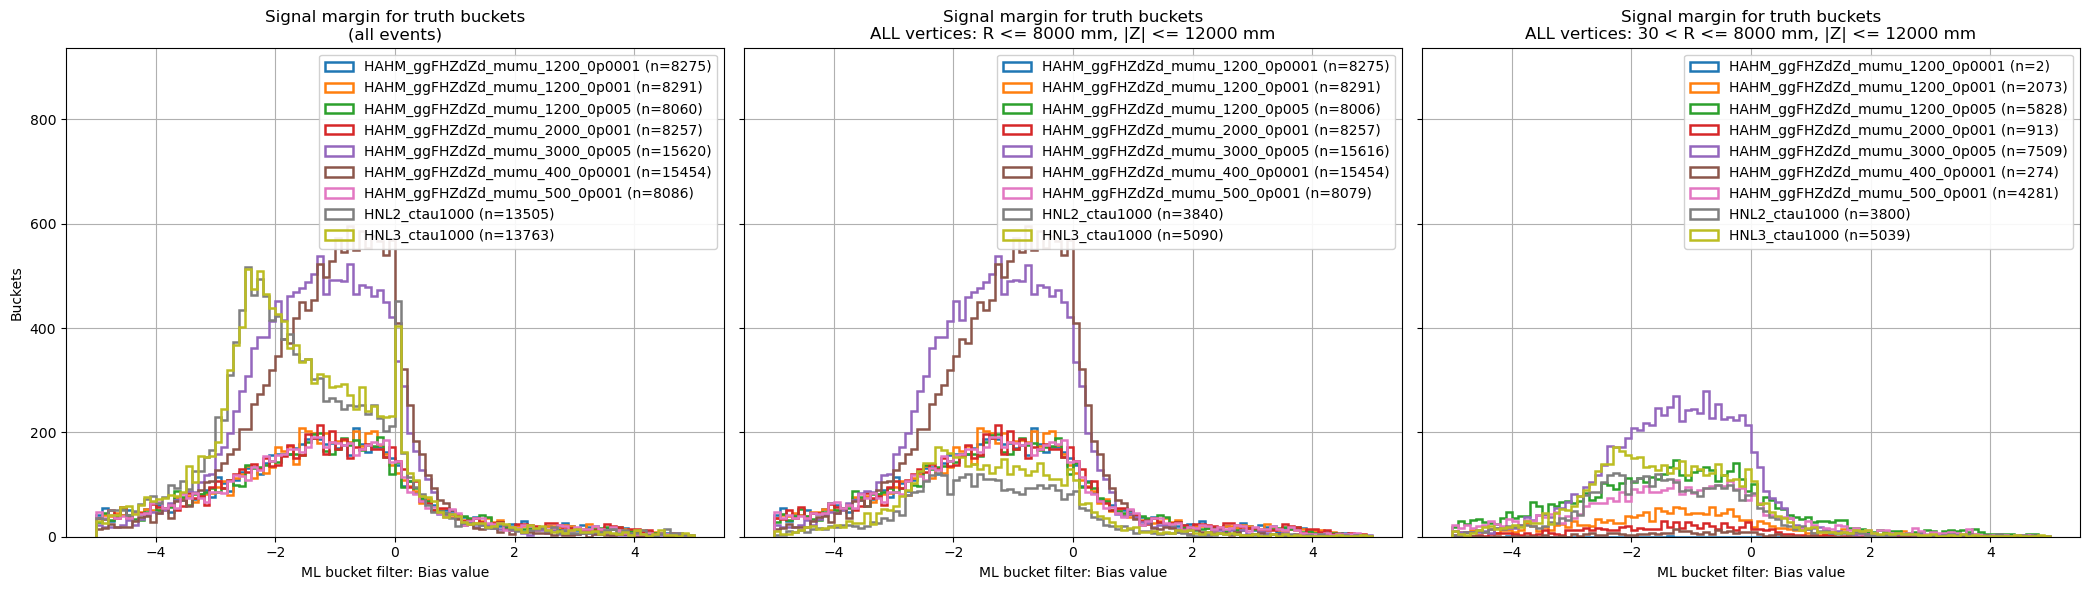

In [4]:
# -------------------------------------------------------------------
# Main
# -------------------------------------------------------------------
RHO_MIN = 30.0 # mm
R_MAX   = 8000.0   # mm
Z_MAX   = 12000.0  # mm

samples = discover_samples(SAMPLE_GLOB)

print("Discovered samples:")
for s, flist in sorted(samples.items()):
    print(f"  {s}: {len(flist)} files")

plot_truth_histograms_by_sample_with_vertex_comparison(
    samples_dict=samples,
    bins=100,
    hist_range=(-5, 5),
    density=False,
    r_min=RHO_MIN,
    r_max=R_MAX,
    z_max=Z_MAX,
)

In [5]:
print_percentage_below_threshold_with_vertex_comparison(
    samples_dict=samples,
    threshold=1,
    r_min=RHO_MIN,
    r_max=R_MAX,
    z_max=Z_MAX,
)


Percentage of truth buckets with bias < 1
Selections are event-level:
  1) all events
  2) events where ALL vertices satisfy R <= 8000.0 mm and |Z| <= 12000.0 mm
  3) events where ALL vertices satisfy 30.0 < R <= 8000.0 mm and |Z| <= 12000.0 mm


  HAHM_ggFHZdZd_mumu_1200_0p0001: all: 91.02% (7532/8275) | R<8000: 91.02% (7532/8275) | 30<R<8000: 100.00% (2/2)
  HAHM_ggFHZdZd_mumu_1200_0p001: all: 91.22% (7563/8291) | R<8000: 91.22% (7563/8291) | 30<R<8000: 91.41% (1895/2073)
  HAHM_ggFHZdZd_mumu_1200_0p005: all: 91.30% (7359/8060) | R<8000: 91.31% (7310/8006) | 30<R<8000: 91.15% (5312/5828)
  HAHM_ggFHZdZd_mumu_2000_0p001: all: 90.76% (7494/8257) | R<8000: 90.76% (7494/8257) | 30<R<8000: 90.58% (827/913)
  HAHM_ggFHZdZd_mumu_3000_0p005: all: 97.21% (15184/15620) | R<8000: 97.21% (15180/15616) | 30<R<8000: 97.39% (7313/7509)
  HAHM_ggFHZdZd_mumu_400_0p0001: all: 97.44% (15058/15454) | R<8000: 97.44% (15058/15454) | 30<R<8000: 97.45% (267/274)
  HAHM_ggFHZdZd_mumu_500_0p001: all: 91.52% (7400/8086) | R<8000: 91.51% (7393/8079) | 30<R<8000: 91.47% (3916/4281)
  HNL2_ctau1000: all: 95.59% (12909/13505) | R<8000: 95.16% (3654/3840) | 30<R<8000: 95.16% (3616/3800)
  HNL3_ctau1000: all: 95.36% (13124/13763) | R<8000: 95.23% (4847/5090)

# Segments

In [10]:
# ----------------------------------------------------------------------
# Segments/event, with and without vertex calo-envelope requirement
# ----------------------------------------------------------------------
def load_segments_per_event(file_list, bucket_tree_name="MuonBucketDump"):
    """
    Return a pandas Series:
        index   = event_hash
        values  = total number of segments in that event
    computed from MuonBucketDump.
    """
    if not file_list:
        raise ValueError("file_list is empty")

    with uproot.open(file_list[0]) as f:
        all_branches = list(f[bucket_tree_name].keys())

    evh_key = find_common_event_hash_key(all_branches)

    if "segmentPositionX" in all_branches:
        seg_key = "segmentPositionX"
    elif "mb_segmentPositionX" in all_branches:
        seg_key = "mb_segmentPositionX"
    else:
        raise KeyError("Could not find segmentPositionX branch")

    arrays_per_file = []
    for fname in file_list:
        with uproot.open(fname) as f:
            arrs = f[bucket_tree_name].arrays([evh_key, seg_key], library="ak")
            arrays_per_file.append(arrs)

    event_hash = flatten_common_event_hash(
        ak.to_numpy(ak.concatenate([arrs[evh_key] for arrs in arrays_per_file], axis=0))
    )
    segment_x = ak.concatenate([arrs[seg_key] for arrs in arrays_per_file], axis=0)

    nseg_per_entry = ak.to_numpy(ak.num(segment_x, axis=1))

    df = pd.DataFrame({
        "event_hash": event_hash,
        "nseg_entry": nseg_per_entry,
    })

    # Sum segments over all bucket entries with same event hash
    return df.groupby("event_hash", sort=False)["nseg_entry"].sum()




def plot_segments_comparison(
    samples_dict,
    bins=100,
    hist_range=None,
    density=False,
    r_min=30.0, 
    r_max=8000.0,
    z_max=12000.0,
):
    fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

    ax_all = axes[0]
    ax_rlt = axes[1]
    ax_band = axes[2]
    
    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            segments_per_event = load_segments_per_event(file_list)
            vals_all = segments_per_event.to_numpy()

            kept_hashes_rlt = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=None,
                r_max=r_max,
                z_max=z_max,
            )

            vals_rlt = segments_per_event[
                segments_per_event.index.isin(kept_hashes_rlt)
            ].to_numpy()

            kept_hashes_band = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=r_min,
                r_max=r_max,
                z_max=z_max,
            )

            vals_band = segments_per_event[
                segments_per_event.index.isin(kept_hashes_band)
            ].to_numpy()

            if len(vals_all) > 0:
                ax_all.hist(
                    vals_all,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_all)})",
                )

            if len(vals_rlt) > 0:
                ax_rlt.hist(
                    vals_rlt,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_rlt)})",
                )

            if len(vals_band) > 0:
                ax_band.hist(
                    vals_band,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_band)})",
                )

            mean_all = vals_all.mean() if len(vals_all) else float("nan")
            mean_rlt = vals_rlt.mean() if len(vals_rlt) else float("nan")
            mean_band = vals_band.mean() if len(vals_band) else float("nan")

            print(
                f"[OK] {sample_name}: "
                f"all={len(vals_all)}, mean_all={mean_all:.2f}; "
                f"R<{r_max:.0f}={len(vals_rlt)}, mean_rlt={mean_rlt:.2f}; "
                f"{r_min:.0f}<R<{r_max:.0f}={len(vals_band)}, mean_band={mean_band:.2f}"
            )

        except Exception as e:
            print(f"[ERROR] Failed for sample {sample_name}: {e}")

    ax_all.set_xlabel("Number of segments per event")
    ax_all.set_ylabel("Normalized events" if density else "Events")
    ax_all.set_title("Segments per event\n(all events)")
    ax_all.grid(True)
    ax_all.legend(loc="upper right", framealpha=0.9)

    ax_rlt.set_xlabel("Number of segments per event")
    ax_rlt.set_title(
        f"Segments per event\nALL vertices: R <= {r_max:.0f} mm, |Z| <= {z_max:.0f} mm"
    )
    ax_rlt.grid(True)
    ax_rlt.legend(loc="upper right", framealpha=0.9)

    ax_band.set_xlabel("Number of segments per event")
    ax_band.set_title(
        f"Segments per event\nALL vertices: {r_min:.0f} < R <= {r_max:.0f} mm, |Z| <= {z_max:.0f} mm"
    )
    ax_band.grid(True)
    ax_band.legend(loc="upper right", framealpha=0.9)

    ymax0 = ax_all.get_ylim()[1]
    ymax1 = ax_rlt.get_ylim()[1]
    ymax2 = ax_band.get_ylim()[1]
    ymax = max(ymax0, ymax1, ymax2)
    ax_all.set_ylim(0, ymax * 1)
    ax_rlt.set_ylim(0, ymax * 1)
    ax_band.set_ylim(0, ymax * 1)

    plt.tight_layout()
    plt.show()


def print_segments_comparison_stats(samples_dict, r_min=30.0, r_max=8000.0, z_max=12000.0):
    print(f"\nSegments/event comparison")
    print("Selections are event-level:")
    print("  1) all events")
    print(f"  2) events where ALL vertices satisfy R <= {r_max} mm and |Z| <= {z_max} mm")
    print(f"  3) events where ALL vertices satisfy {r_min} < R <= {r_max} mm and |Z| <= {z_max} mm")
    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            segments_per_event = load_segments_per_event(file_list)
            vals_all = segments_per_event.to_numpy()

            kept_hashes_rlt = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=None,
                r_max=r_max,
                z_max=z_max,
            )

            vals_rlt = segments_per_event[
                segments_per_event.index.isin(kept_hashes_rlt)
            ].to_numpy()

            kept_hashes_band = load_vertex_hashes_passing_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_min=r_min,
                r_max=r_max,
                z_max=z_max,
            )

            vals_band = segments_per_event[
                segments_per_event.index.isin(kept_hashes_band)
            ].to_numpy()
            
            if len(vals_all) == 0:
                print(f"  {sample_name}: no events")
                continue

            msg = (
                f"  {sample_name}: "
                f"all n={len(vals_all)}, mean={vals_all.mean():.2f}, max={vals_all.max()}"
            )

            if len(vals_rlt) > 0:
                msg += f" | R<{r_max:.0f} n={len(vals_rlt)}, mean={vals_rlt.mean():.2f}, max={vals_rlt.max()}"
            else:
                msg += f" | R<{r_max:.0f} n=0"

            if len(vals_band) > 0:
                msg += f" | {r_min:.0f}<R<{r_max:.0f} n={len(vals_band)}, mean={vals_band.mean():.2f}, max={vals_band.max()}"
            else:
                msg += f" | {r_min:.0f}<R<{r_max:.0f} n=0"
            print(msg)

        except Exception as e:
            print(f"  {sample_name}: ERROR - {e}")

[OK] HAHM_ggFHZdZd_mumu_1200_0p0001: all=20000, mean_all=152.95; R<8000=20000, mean_rlt=152.95; 30<R<8000=4, mean_band=168.75
[OK] HAHM_ggFHZdZd_mumu_1200_0p001: all=20000, mean_all=152.91; R<8000=20000, mean_rlt=152.91; 30<R<8000=4967, mean_band=153.01
[OK] HAHM_ggFHZdZd_mumu_1200_0p005: all=20000, mean_all=152.51; R<8000=19842, mean_rlt=152.56; 30<R<8000=14460, mean_band=152.80
[OK] HAHM_ggFHZdZd_mumu_2000_0p001: all=20000, mean_all=153.31; R<8000=20000, mean_rlt=153.31; 30<R<8000=2151, mean_band=153.42
[OK] HAHM_ggFHZdZd_mumu_3000_0p005: all=19876, mean_all=10.00; R<8000=19870, mean_rlt=10.00; 30<R<8000=9573, mean_band=10.26
[OK] HAHM_ggFHZdZd_mumu_400_0p0001: all=19874, mean_all=9.08; R<8000=19874, mean_rlt=9.08; 30<R<8000=358, mean_band=9.14
[OK] HAHM_ggFHZdZd_mumu_500_0p001: all=20000, mean_all=152.58; R<8000=19985, mean_rlt=152.59; 30<R<8000=10629, mean_band=152.95
[OK] HNL2_ctau1000: all=17329, mean_all=3.78; R<8000=4757, mean_rlt=6.40; 30<R<8000=4707, mean_band=6.42
[OK] HNL3_

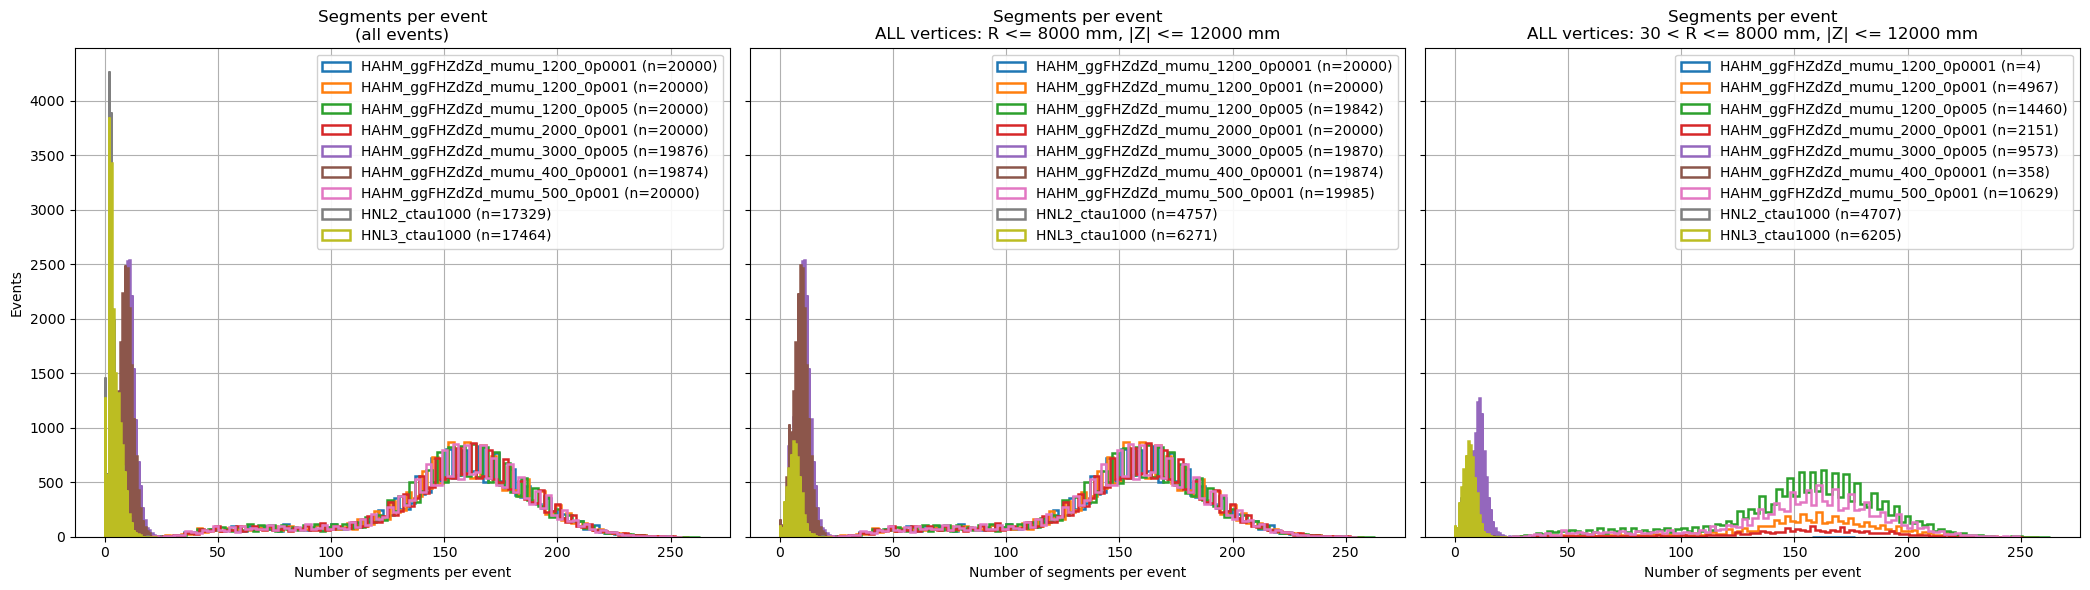

In [11]:
plot_segments_comparison(
    samples_dict=samples,
    bins=100,
    hist_range=None,   # or e.g. (0, 500)
    density=False,
    r_min=30.0,
    r_max=8000.0,
    z_max=12000.0,
)

In [9]:
print_segments_comparison_stats(
    samples_dict=samples,
    r_min=30.0,
    r_max=8000.0,
    z_max=12000.0,
)


Segments/event comparison
Selections are event-level:
  1) all events
  2) events where ALL vertices satisfy R <= 8000.0 mm and |Z| <= 12000.0 mm
  3) events where ALL vertices satisfy 30.0 < R <= 8000.0 mm and |Z| <= 12000.0 mm
  HAHM_ggFHZdZd_mumu_1200_0p0001: all n=20000, mean=152.95, max=253 | R<8000 n=20000, mean=152.95, max=253 | 30<R<8000 n=4, mean=168.75, max=177
  HAHM_ggFHZdZd_mumu_1200_0p001: all n=20000, mean=152.91, max=258 | R<8000 n=20000, mean=152.91, max=258 | 30<R<8000 n=4967, mean=153.01, max=258
  HAHM_ggFHZdZd_mumu_1200_0p005: all n=20000, mean=152.51, max=263 | R<8000 n=19842, mean=152.56, max=263 | 30<R<8000 n=14460, mean=152.80, max=263
  HAHM_ggFHZdZd_mumu_2000_0p001: all n=20000, mean=153.31, max=252 | R<8000 n=20000, mean=153.31, max=252 | 30<R<8000 n=2151, mean=153.42, max=251
  HAHM_ggFHZdZd_mumu_3000_0p005: all n=19876, mean=10.00, max=30 | R<8000 n=19870, mean=10.00, max=30 | 30<R<8000 n=9573, mean=10.26, max=30
  HAHM_ggFHZdZd_mumu_400_0p0001: all n=198